In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import Log
from statsmodels.tools import add_constant
from pygam import LogisticGAM, s, f
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from pathlib import Path

In [2]:
# load and read the data
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(12)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2305,4947-DSMXK,Male,0,Yes,Yes,34,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),97.70,3410,No
5548,4589-IUAJB,Male,0,Yes,No,70,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.25,1724.15,No
1809,9606-PBKBQ,Male,1,Yes,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.00,2642.05,Yes
1771,7156-MHUGY,Male,1,No,No,13,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.50,1201.15,Yes
6414,3472-QPRCH,Male,0,Yes,Yes,40,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.25,1006.9,No
3114,0867-LDTTC,Male,0,No,No,5,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),75.15,392.65,No
5352,6559-PDZLR,Male,0,No,No,26,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,98.65,2537,No
4767,1064-FBXNK,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.85,19.85,No
3214,0549-CYCQN,Male,1,No,No,51,Yes,Yes,Fiber optic,No,...,No,No,No,No,One year,Yes,Bank transfer (automatic),79.60,3974.7,No
1330,0661-WCQNQ,Male,0,Yes,No,22,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,Yes,Credit card (automatic),56.25,1292.2,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

From this analysis, we can see that there is a huge proportion of 'No' than 'Yes'.

In [6]:
# convert the data type of 'Churn'
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [7]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [9]:
# inspect the categorical variables
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"{col}")
    print(df[col].value_counts(dropna=False))

customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No intern

/var/folders/7n/z5n19rw11tddr4w2vzvb382m0000gn/T/ipykernel_85240/3468324510.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


In [10]:
# separate the numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:")
print(numeric_cols)

print("\nCategorical:")
print(categorical_cols)

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn']

Categorical:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


/var/folders/7n/z5n19rw11tddr4w2vzvb382m0000gn/T/ipykernel_85240/2056872100.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [11]:
# I see that churn is included, so, I should remove that since it is our dependent variable
numeric_cols = [col for col in numeric_cols if col != "Churn"]

In [12]:
numeric_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [14]:
df = df.dropna(subset=["TotalCharges"]).copy()

In [15]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:")
print(numeric_cols)

print("\nCategorical:")
print(categorical_cols)

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/7n/z5n19rw11tddr4w2vzvb382m0000gn/T/ipykernel_85240/2776488965.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [17]:
df = df.drop(columns=["customerID"])

In [18]:
continuous_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]  # because we don't want to inclide the Senior Citizen column

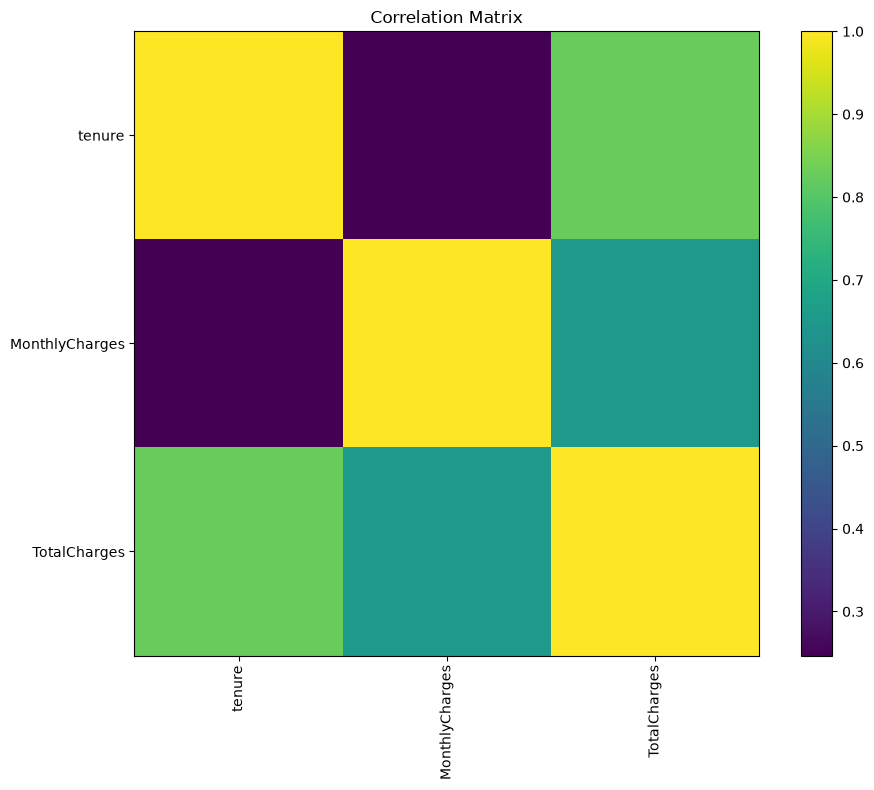

In [19]:
corr = df[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.colorbar(im)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# had to use chatGPT for creating this a little bit, because I have only created correlation matrices using R.

I see that there is high correlation between 'tenure' and 'TotalCharges'.

In [20]:
df[continuous_cols].corr().round(3)

# used chatGPT for this

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.247,0.826
MonthlyCharges,0.247,1.000,0.651
TotalCharges,0.826,0.651,1.000


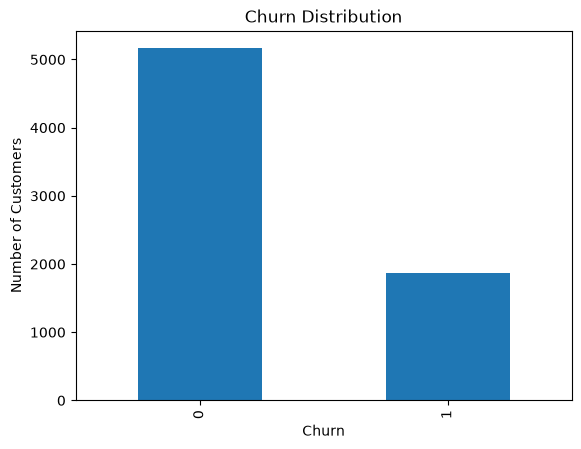

In [21]:
churn_counts = df["Churn"].value_counts()

churn_counts.plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution")

plt.show()

In [22]:
# categorical variables
categorical_cols = [col for col in df.columns if col not in continuous_cols + ["Churn"]]

for col in categorical_cols:

    churn_rate = df.groupby(col)["Churn"].mean().sort_values()

    print(f"\nChurn rate by {col}:")
    print(churn_rate)


Churn rate by gender:
gender
Male      0.262046
Female    0.269595
Name: Churn, dtype: float64

Churn rate by SeniorCitizen:
SeniorCitizen
0    0.236503
1    0.416813
Name: Churn, dtype: float64

Churn rate by Partner:
Partner
Yes    0.197171
No     0.329761
Name: Churn, dtype: float64

Churn rate by Dependents:
Dependents
Yes    0.155312
No     0.312791
Name: Churn, dtype: float64

Churn rate by PhoneService:
PhoneService
No     0.250000
Yes    0.267475
Name: Churn, dtype: float64

Churn rate by MultipleLines:
MultipleLines
No phone service    0.250000
No                  0.250812
Yes                 0.286485
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
No             0.074342
DSL            0.189983
Fiber optic    0.418928
Name: Churn, dtype: float64

Churn rate by OnlineSecurity:
OnlineSecurity
No internet service    0.074342
Yes                    0.146402
No                     0.417787
Name: Churn, dtype: float64

Churn rate by OnlineBackup:
Online

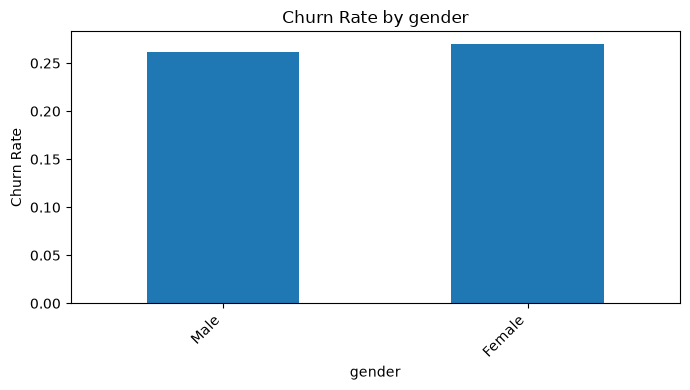

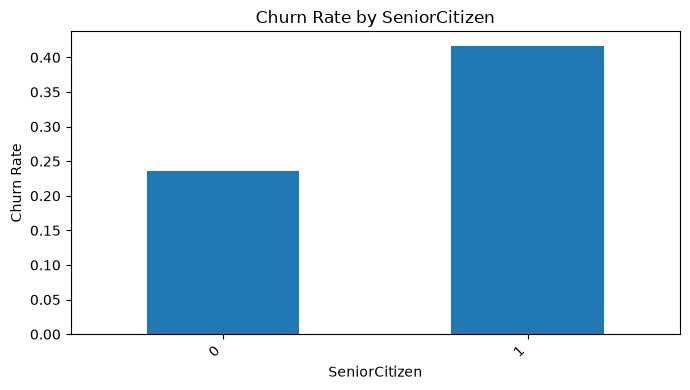

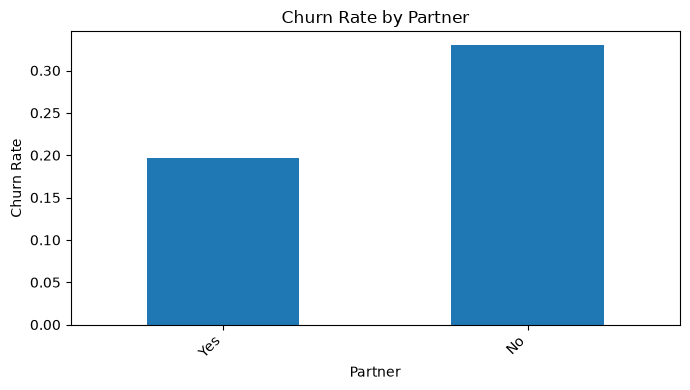

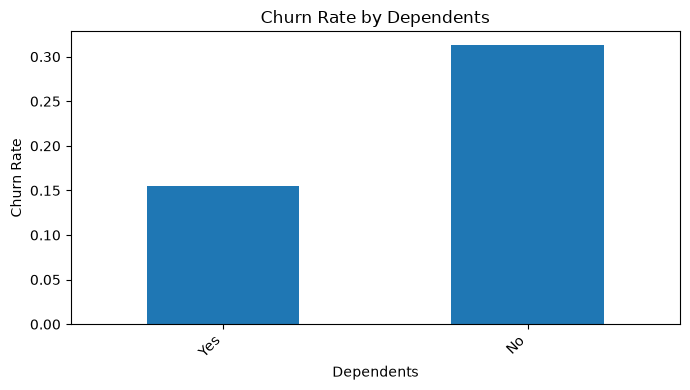

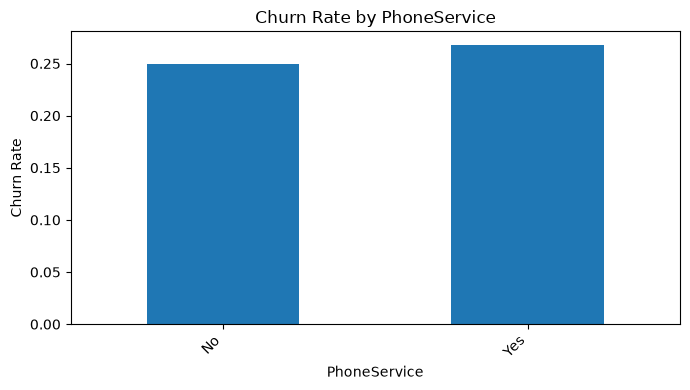

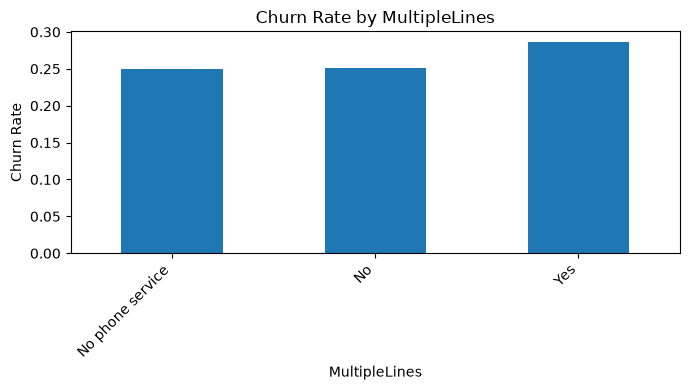

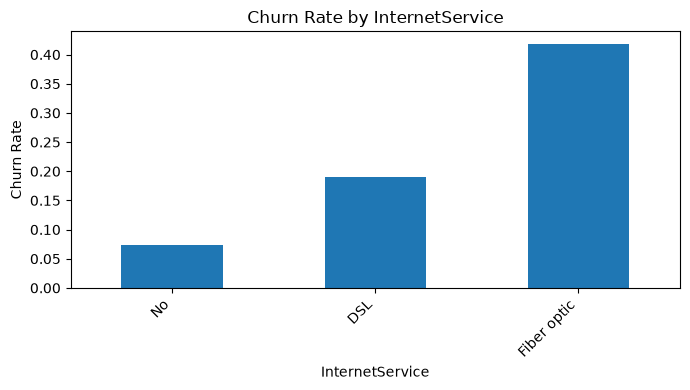

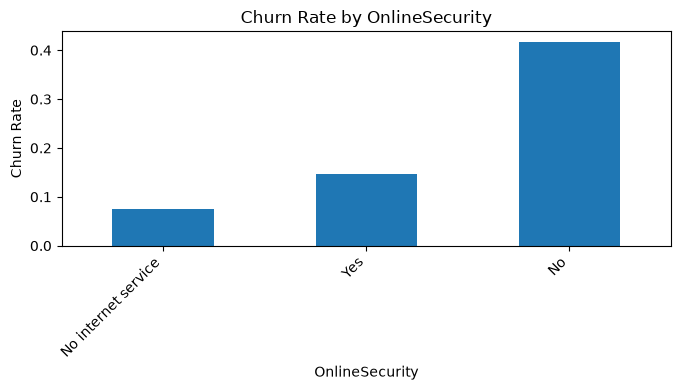

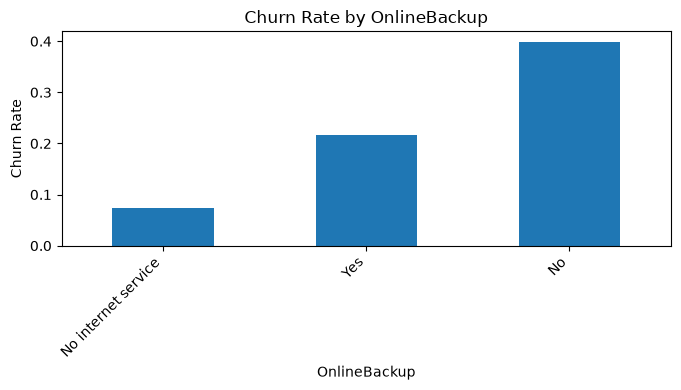

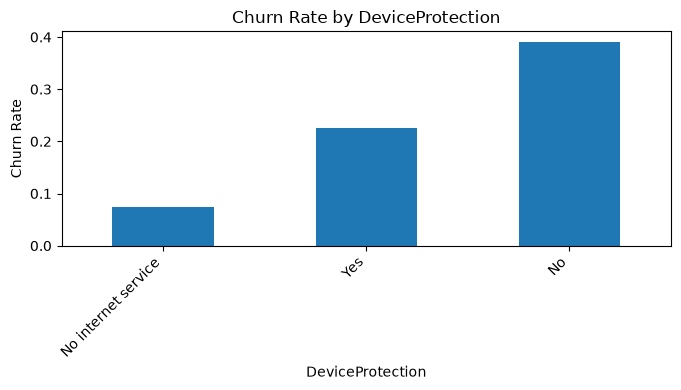

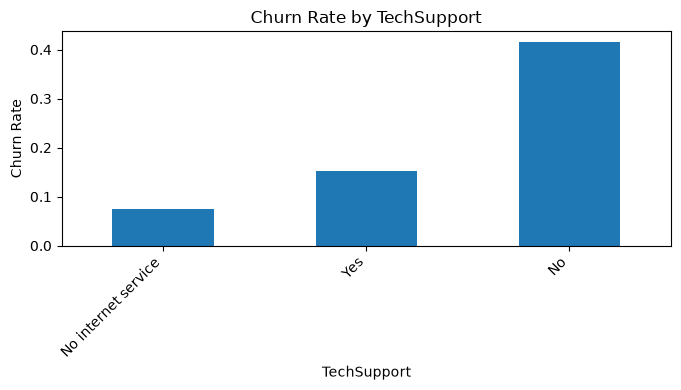

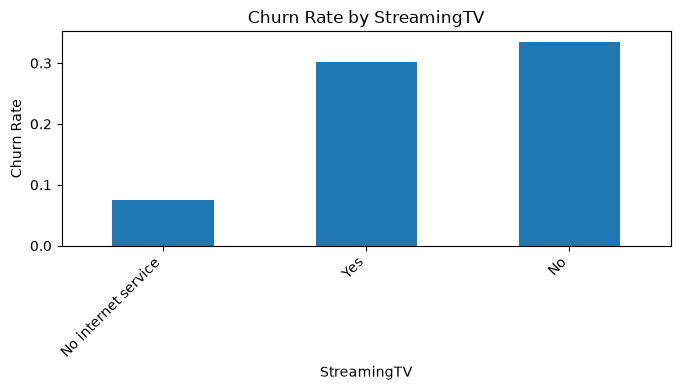

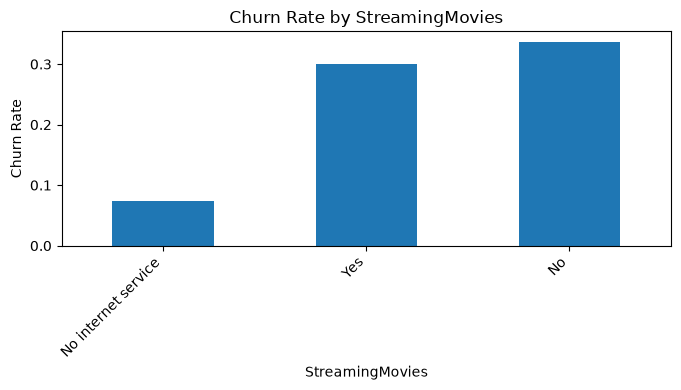

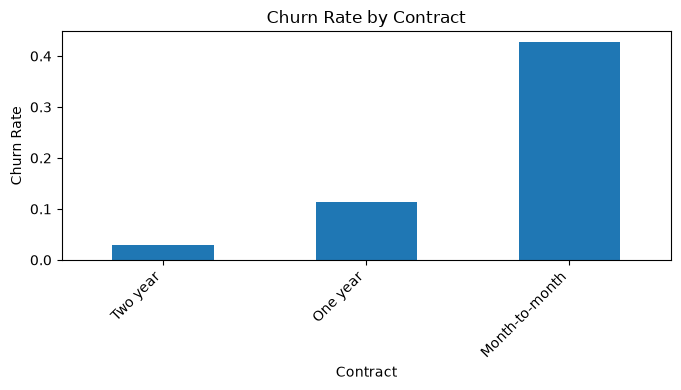

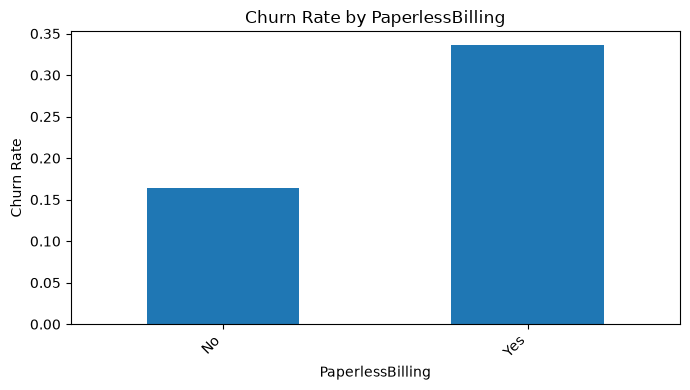

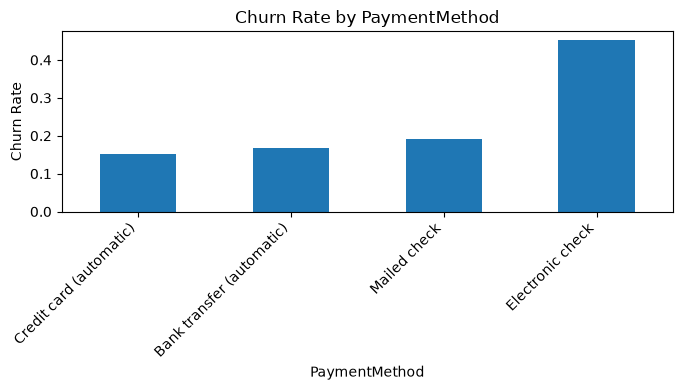

In [23]:
for col in categorical_cols:

    churn_rate = df.groupby(col)["Churn"].mean().sort_values()

    churn_rate.plot(kind="bar", figsize=(7, 4))

    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# had to use chatGPT for resolving syntax issues

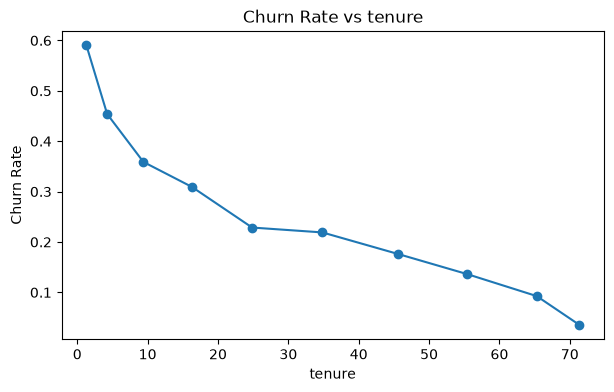

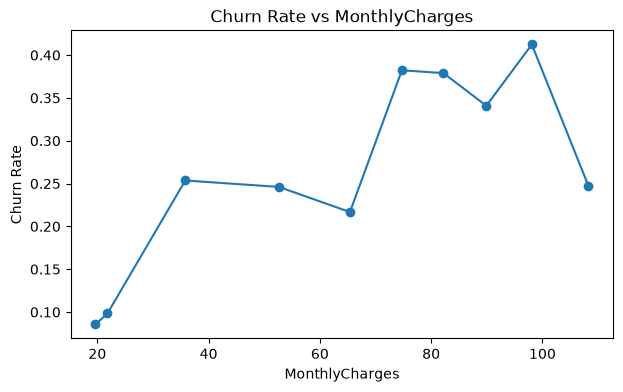

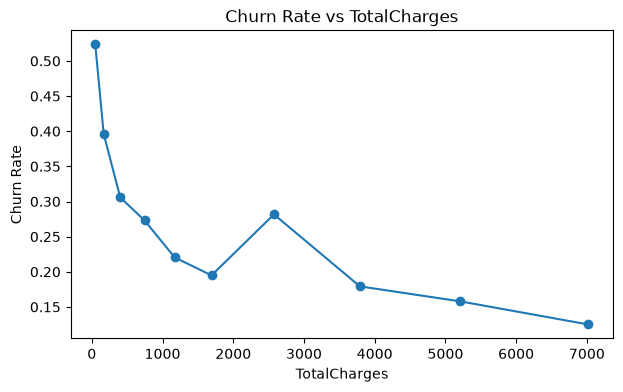

In [24]:
for col in continuous_cols:

    temp = df[[col, "Churn"]].copy()

    temp["bin"] = pd.qcut(temp[col], q=10, duplicates="drop")

    churn_by_bin = temp.groupby("bin", observed=False).agg(
        mean_value=(col, "mean"), churn_rate=("Churn", "mean")
    )

    plt.figure(figsize=(7, 4))

    plt.plot(churn_by_bin["mean_value"], churn_by_bin["churn_rate"], marker="o")

    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate vs {col}")

    plt.show()

    # had to use chatGPT because my code was getting bigger and a bit difficult to keep up. So, I had chatGPT come up with a simpler and cleaner approach.

In [25]:
df.duplicated().sum()

np.int64(22)

Before I removed 'customerID', it showed there were unique values, but when I removed them, I saw there were 22 duplicates. After careful thought, I have realized that they belong to different customer IDs which represent customers with identical observed characteristics rather than duplicate customer records. I would say that independence is not violated.

In [26]:
# VIF check
X = df.drop(columns=["Churn"])
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [27]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

X_encoded.head()

# used AI for encoding

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [28]:
X_encoded.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No inter

In [29]:
X_vif = add_constant(X_encoded)

vif_data = pd.DataFrame()

vif_data["Variable"] = X_encoded.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_encoded.values, i) for i in range(X_encoded.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

vif_data

# used chatGPT for this, because i have only doen this in R

/var/folders/7n/z5n19rw11tddr4w2vzvb382m0000gn/T/ipykernel_85240/1304093266.py:8: UserWarning: The design matrix is poorly conditioned (condition number=4.42e+18). VIF calculations may be numerically unstable.
  variance_inflation_factor(X_encoded.values, i) for i in range(X_encoded.shape[1])
/Users/sebinescaria/Downloads/Assumption Junction/XAI-interpretable-churn-model/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/sebinescaria/Downloads/Assumption Junction/XAI-interpretable-churn-model/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/sebinescaria/Downloads/Assumption Junction/XAI-interpretable-churn-model/.ven

,Variable,VIF
11,InternetService_No,1.000800e+15
12,OnlineSecurity_No internet service,1.000800e+15
20,StreamingTV_No internet service,1.000800e+15
18,TechSupport_No internet service,1.000800e+15
16,DeviceProtection_No internet service,1.000800e+15
7,PhoneService_Yes,1.000800e+15
8,MultipleLines_No phone service,1.000800e+15
14,OnlineBackup_No internet service,1.000800e+15
22,StreamingMovies_No internet service,1.000800e+15
2,MonthlyCharges,8.660896e+02


In [30]:
cols = [
    "InternetService_No",
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service",
]

X_encoded[cols].corr()

,InternetService_No,OnlineSecurity_No internet service,OnlineBackup_No internet service,DeviceProtection_No internet service,TechSupport_No internet service,StreamingTV_No internet service,StreamingMovies_No internet service
InternetService_No,1.0,1.0,1.0,1.0,1.0,1.0,1.0
OnlineSecurity_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0
OnlineBackup_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0
DeviceProtection_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0
TechSupport_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0
StreamingTV_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0
StreamingMovies_No internet service,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [31]:
df_model = df.copy()

In [32]:
internet_addons = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

for col in internet_addons:
    df_model[col] = (df_model[col] == "Yes").astype(int)

In [33]:
df_model["MultipleLines"] = (df_model["MultipleLines"] == "Yes").astype(int)

In [34]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_cols:
    df_model[col] = df_model[col].map({"No": 0, "Yes": 1})

In [35]:
df_model["gender"] = df_model["gender"].map({"Female": 0, "Male": 1})

In [36]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [37]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [38]:
X_model = df_model.drop(columns=["Churn"])

X_encoded_model = pd.get_dummies(X_model, drop_first=True, dtype=int)

In [39]:
X_encoded_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,0,0,0,0,1,0


In [40]:
X_vif = add_constant(X_encoded_model)

vif_data = pd.DataFrame(
    {
        "Variable": X_vif.columns,
        "VIF": [
            variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
        ],
    }
)

vif_data = vif_data[vif_data["Variable"] != "const"].sort_values("VIF", ascending=False)

vif_data

,Variable,VIF
15,MonthlyCharges,866.089640
17,InternetService_Fiber optic,148.500814
18,InternetService_No,104.213701
6,PhoneService,34.893857
13,StreamingMovies,24.156394
12,StreamingTV,24.080019
16,TotalCharges,10.811490
5,tenure,7.584453
7,MultipleLines,7.289761
10,DeviceProtection,6.924754


In [41]:
X = X_encoded_model.copy()
y = df_model["Churn"].copy()

In [42]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
for i, col in enumerate(X_train.columns):
    print(i, col)

0 gender
1 SeniorCitizen
2 Partner
3 Dependents
4 tenure
5 PhoneService
6 MultipleLines
7 OnlineSecurity
8 OnlineBackup
9 DeviceProtection
10 TechSupport
11 StreamingTV
12 StreamingMovies
13 PaperlessBilling
14 MonthlyCharges
15 TotalCharges
16 InternetService_Fiber optic
17 InternetService_No
18 Contract_One year
19 Contract_Two year
20 PaymentMethod_Credit card (automatic)
21 PaymentMethod_Electronic check
22 PaymentMethod_Mailed check


In [45]:
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

terms = None

for i, col in enumerate(X_train.columns):

    if col in continuous_cols:
        term = s(i)
    else:
        term = f(i)

    if terms is None:
        terms = term
    else:
        terms += term

In [46]:
gam = LogisticGAM(terms)

gam.fit(X_train.values, y_train.values)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=f(0) + f(1) + f(2) + f(3) + s(4) + f(5) + f(6) + f(7) + f(8) + f(9) + f(10) + f(11) + f(12) + f(13) + s(14) + s(15) + f(16) + f(17) + f(18) + f(19) + f(20) + f(21) + f(22) + intercept,
   tol=0.0001, verbose=False)

In [47]:
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     55.9574
Link Function:                        LogitLink Log Likelihood:                                   -2243.02
Number of Samples:                         5625 AIC:                                             4597.9547
                                                AICc:                                            4599.1407
                                                UBRE:                                               2.8254
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3113
Feature Function                  Lam

/var/folders/7n/z5n19rw11tddr4w2vzvb382m0000gn/T/ipykernel_85240/3358381670.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


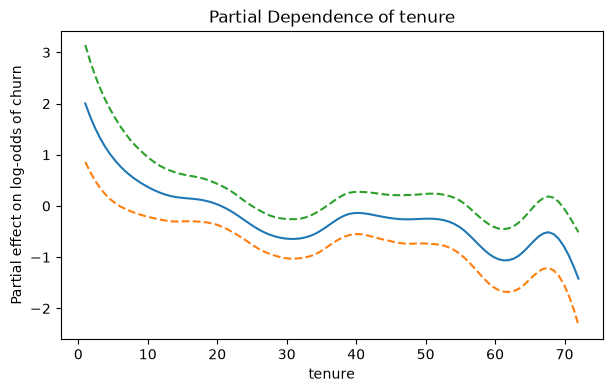

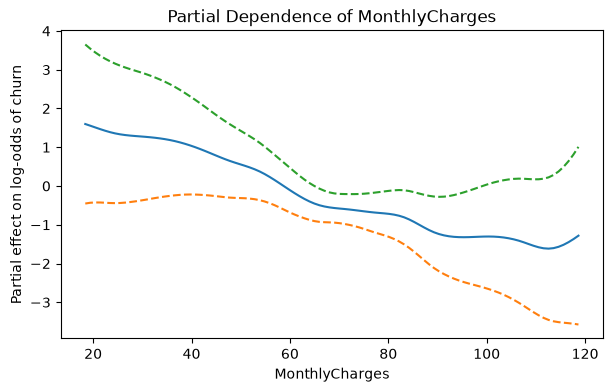

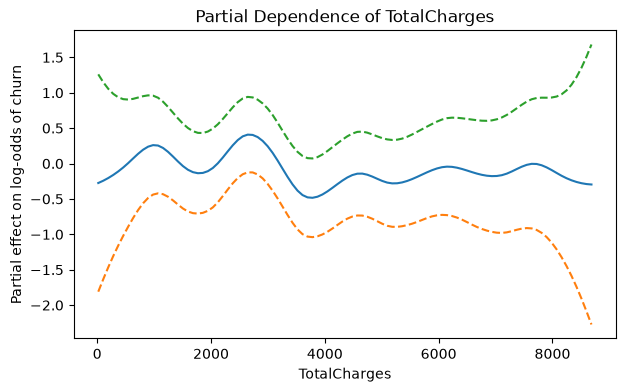

In [48]:
smooth_features = [(4, "tenure"), (14, "MonthlyCharges"), (15, "TotalCharges")]

for term_idx, name in smooth_features:

    XX = gam.generate_X_grid(term=term_idx)

    pdep, confi = gam.partial_dependence(term=term_idx, X=XX, width=0.95)

    plt.figure(figsize=(7, 4))

    plt.plot(XX[:, term_idx], pdep)

    plt.plot(XX[:, term_idx], confi[:, 0], linestyle="--")

    plt.plot(XX[:, term_idx], confi[:, 1], linestyle="--")

    plt.xlabel(name)
    plt.ylabel("Partial effect on log-odds of churn")
    plt.title(f"Partial Dependence of {name}")

    plt.show()

# used chatGPT because i haven't created a partial dependency graphs before

In [49]:
y_prob = gam.predict_proba(X_test.values)

In [50]:
y_prob[:10]

array([0.01238143, 0.58321273, 0.01316613, 0.2158086 , 0.11102273,
       0.44929627, 0.02722278, 0.09597822, 0.66332928, 0.01017672])

In [51]:
y_pred = (y_prob >= 0.5).astype(int)

In [52]:
results = pd.DataFrame(
    {
        "Actual_Churn": y_test.values,
        "Predicted_Probability": y_prob,
        "Predicted_Churn": y_pred,
    }
)

results.head(10)

,Actual_Churn,Predicted_Probability,Predicted_Churn
0,0,0.012381,0
1,0,0.583213,1
2,0,0.013166,0
3,1,0.215809,0
4,0,0.111023,0
5,1,0.449296,0
6,0,0.027223,0
7,0,0.095978,0
8,1,0.663329,1
9,0,0.010177,0


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7960199004975125
Precision: 0.637223974763407
Recall: 0.5401069518716578
F1 Score: 0.5846599131693199
ROC-AUC: 0.8411627521729452

Confusion Matrix:
[[918 115]
 [172 202]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



**About Model Assumptions:**
GAM relaxes the linearity assumption that numeric predictors have strictly linear functional relationships with response to the link function, since they are represented with smooth functions.

Talking about the independence assumption, before I removed the customerID column, I could see that all the rows were unique, but after I removed them, I see there are 22 duplicate values. I am assuming that they are rows which has information about different individuals. So, I would assume that the observations are independent. 

Normality of residules doesn't apply for binomial logistic GAMs because we are using a model that assumes a binominal distribution for Churn and uses a logit function. 

Homoscedasticity doesn't get applied for binomial logistic GAMs because conditional variance depends on the predicted probability.

Talking about basis functions and smoothness, pyGAM represents each smooth continuous
effect using spline basis functions. In this analysis, the default pyGAM
settings were used for the number of splines and smoothing penalty.

(used chatGPT to help me articulate my thoughts accurately.)
The partial dependence plots show the nonlinear relationships produced by the GAM between the continuous predictors and customer churn while accounting for the other variables in the model. Tenure shows the clearest pattern, with newer customers generally having a higher contribution to churn risk and the effect decreasing as tenure increases. The effectxs of MonthlyCharges and TotalCharges are less straightforward and show greater uncertainty, particularly toward the extremes of their ranges. These effects should also be interpreted cautiously because the EDA identified substantial multicollinearity among charges, tenure, and several service-related variables.

**Overall Results and Interpretation:**
Overall, the Logistic GAM provides a reasonably strong model for predicting customer churn. After some data cleaning, the analysis identified meaningful relationships between churn and several customer characteristics, while also revealing substantial structural multicollinearity among variables such as service subscriptions, MonthlyCharges, TotalCharges, and tenure. The GAM was able to model nonlinear effects for tenure, MonthlyCharges, and TotalCharges and achieved about 80% accuracy with an ROC-AUC of approximately 0.84, indicating good ability to distinguish between customers who churn and those who do not. However, the model’s churn recall of about 54% shows that it still misses a considerable proportion of actual churners at the 0.50 classification threshold, so the model performs well overall but has room for improvement in identifying customers who are most at risk of churning.